**LAB 1: Regression**

**Simple Linear Regression**  

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# โหลดข้อมูล
df = pd.read_csv("data.csv")

# ลบข้อมูลที่หายไป
df = df.dropna()

# กำหนด X และ y
X = df[['Duration']]
y = df['Calories']

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# สร้างโมเดล
model = LinearRegression()

# ฝึกโมเดล
model.fit(X_train, y_train)

# ทำนายผล
y_pred = model.predict(X_test)

# แสดงสมการ
print("Intercept =", model.intercept_)
print("Slope =", model.coef_[0])

Intercept = 5.229634541828489
Slope = 5.755384017808211


การวาดกราฟ

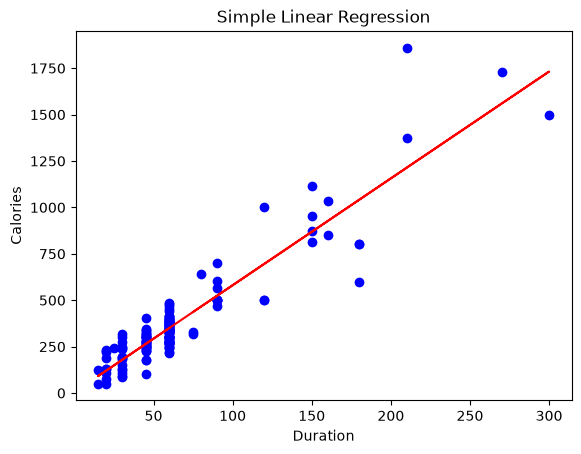

In [2]:
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.xlabel("Duration")
plt.ylabel("Calories")
plt.title("Simple Linear Regression")
plt.show()

กราฟจะประกอบด้วย

จุดสีน้ำเงิน = ข้อมูลจริง
เส้นสีแดง = เส้น Regression Line

การประเมินโมเดล

In [3]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE =", mean_squared_error(y_test, y_pred))
print("R² =", r2_score(y_test, y_pred))

MSE = 8245.553232781873
R² = 0.7471444773251994


ความหมายของผลลัพธ์

MSE (Mean Squared Error) ยิ่งน้อยยิ่งดี
R² Score มีค่าอยู่ระหว่าง 0–1
ใกล้ 1 = โมเดลทำนายได้ดี
ใกล้ 0 = โมเดลทำนายได้ไม่ดี

---

**Multiple Linear Regression**

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# โหลดข้อมูล
df = pd.read_csv("data.csv")

# ลบข้อมูลที่หายไป
df = df.dropna()

# กำหนดตัวแปรอิสระ (หลายตัว)
X = df[['Duration', 'Pulse', 'Maxpulse']]

# ตัวแปรตาม
y = df['Calories']

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# สร้างโมเดล
model = LinearRegression()

# ฝึกโมเดล
model.fit(X_train, y_train)

# ทำนายผล
y_pred = model.predict(X_test)

# แสดงผล
print("Intercept =", model.intercept_)

print("\nCoefficients")
print("Duration =", model.coef_[0])
print("Pulse =", model.coef_[1])
print("Maxpulse =", model.coef_[2])

Intercept = -435.5672296133219

Coefficients
Duration = 5.791205245570674
Pulse = 1.6709044493508445
Maxpulse = 1.9297061332597059


---

**ประเมินโมเดล**

In [5]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE =", mse)
print("R² Score =", r2)

MSE = 4354.413282161514
R² Score = 0.8664689420685995


**ทดลองทำนายข้อมูลใหม่**

In [6]:
import pandas as pd

new_data = pd.DataFrame({
    'Duration': [60],
    'Pulse': [110],
    'Maxpulse': [130]
})

prediction = model.predict(new_data)

print("Predicted Calories =", prediction[0])

Predicted Calories = 346.5663718732731


---


**Calories Prediction**

คือการสร้างโมเดล Machine Learning เพื่อ ทำนายอายุ (Age) จากข้อมูลที่เกี่ยวข้อง เช่น ส่วนสูง น้ำหนัก ใบหน้า หรือข้อมูลสุขภาพ

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# โหลดข้อมูล
df = pd.read_csv("data.csv")

# ลบข้อมูลที่หายไป
df = df.dropna()

# กำหนดตัวแปรอิสระ (Features)
X = df[['Duration', 'Pulse', 'Maxpulse']]

# กำหนดตัวแปรตาม (Target)
y = df['Calories']

# แบ่งข้อมูลเป็น Train และ Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# สร้างโมเดล
model = LinearRegression()

# ฝึกโมเดล
model.fit(X_train, y_train)

# ทำนายข้อมูลชุดทดสอบ
y_pred = model.predict(X_test)

# แสดงสมการ
print("Intercept =", model.intercept_)
print("Coefficient Duration =", model.coef_[0])
print("Coefficient Pulse =", model.coef_[1])
print("Coefficient Maxpulse =", model.coef_[2])

# ประเมินโมเดล
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error (MSE) =", mse)
print("R² Score =", r2)

# ทดลองทำนายข้อมูลใหม่
new_data = pd.DataFrame({
    'Duration': [60],
    'Pulse': [110],
    'Maxpulse': [130]
})

prediction = model.predict(new_data)

print("\nPredicted Calories =", prediction[0])

Intercept = -435.5672296133219
Coefficient Duration = 5.791205245570674
Coefficient Pulse = 1.6709044493508445
Coefficient Maxpulse = 1.9297061332597059

Mean Squared Error (MSE) = 4354.413282161514
R² Score = 0.8664689420685995

Predicted Calories = 346.5663718732731


อธิบายผลลัพธ์  
Intercept คือค่าคงที่ของสมการ  
Coefficient คือค่าสัมประสิทธิ์ของแต่ละตัวแปร  
MSE ยิ่งต่ำยิ่งดี  
R² Score ยิ่งใกล้ 1 ยิ่งดี (เช่น 0.81 หมายถึงโมเดลอธิบายข้อมูลได้ประมาณ 81%)  
Predicted Calories คือจำนวนแคลอรีที่โมเดลทำนายจากข้อมูลใหม่

**LAB 2: Classification**

**Preparing Classification Data**

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

# อ่านข้อมูล
df = pd.read_csv("data.csv")

# สร้าง Class
# Calories >= 300 เป็น High (1)
# Calories < 300 เป็น Low (0)
df["Class"] = (df["Calories"] >= 300).astype(int)

# กำหนด Feature และ Target
X = df[["Duration", "Pulse", "Maxpulse"]]
y = df["Class"]

# แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (135, 3)
X_test : (34, 3)
y_train: (135,)
y_test : (34,)


**Decision Boundary Visualization**

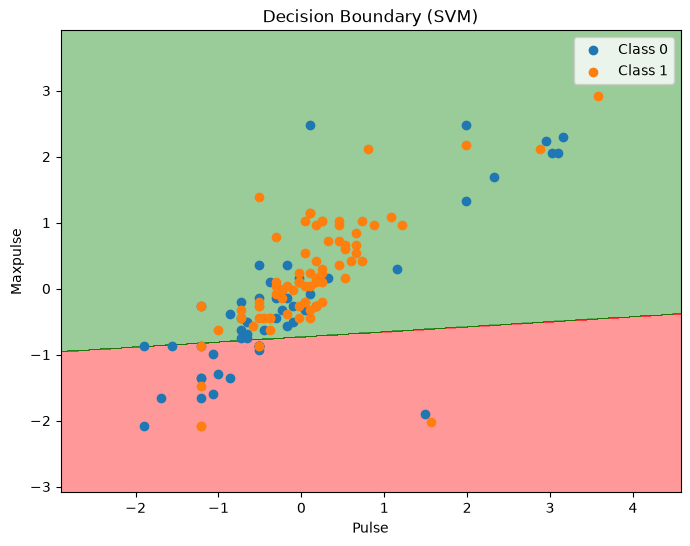

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
import numpy as np

# อ่านข้อมูล
df = pd.read_csv("data.csv")

# สร้าง Class
df["Class"] = (df["Calories"] >= 300).astype(int)

# เลือก 2 Features
X = df[["Pulse", "Maxpulse"]].values
y = df["Class"].values

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Standardize
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Train SVM
classifier = SVC(kernel='linear', random_state=42)
classifier.fit(X_train, y_train)

# สร้าง Decision Boundary
X1, X2 = np.meshgrid(
    np.arange(X_train[:, 0].min()-1, X_train[:, 0].max()+1, 0.01),
    np.arange(X_train[:, 1].min()-1, X_train[:, 1].max()+1, 0.01)
)

plt.figure(figsize=(8,6))

plt.contourf(
    X1,
    X2,
    classifier.predict(
        np.array([X1.ravel(), X2.ravel()]).T
    ).reshape(X1.shape),
    alpha=0.4,
    cmap=ListedColormap(('red', 'green'))
)

for i, j in enumerate(np.unique(y_train)):
    plt.scatter(
        X_train[y_train == j, 0],
        X_train[y_train == j, 1],
        label=f'Class {j}'
    )

plt.title("Decision Boundary (SVM)")
plt.xlabel("Pulse")
plt.ylabel("Maxpulse")
plt.legend()
plt.show()

**Logistic Regression**

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# อ่านข้อมูล
df = pd.read_csv("data.csv")

# สร้าง Class จาก Calories
df["Class"] = (df["Calories"] >= 300).astype(int)

# เลือก Features
X = df[["Duration", "Pulse", "Maxpulse"]]
y = df["Class"]

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# สร้างโมเดล Logistic Regression
model = LogisticRegression(random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# ผลลัพธ์
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.8823529411764706

Confusion Matrix
[[12  3]
 [ 1 18]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.86      0.95      0.90        19

    accuracy                           0.88        34
   macro avg       0.89      0.87      0.88        34
weighted avg       0.89      0.88      0.88        34



**Gender Prediction**

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# อ่านข้อมูล
df = pd.read_csv("data.csv")

# สร้าง Class
df["Class"] = (df["Calories"] >= 300).astype(int)

# Features และ Target
X = df[["Duration", "Pulse", "Maxpulse"]]
y = df["Class"]

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# ทำนายผล
y_pred = model.predict(X_test)

# แสดงผล
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8823529411764706

Confusion Matrix
[[12  3]
 [ 1 18]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.86      0.95      0.90        19

    accuracy                           0.88        34
   macro avg       0.89      0.87      0.88        34
weighted avg       0.89      0.88      0.88        34



**Confusion Matrix**

Confusion Matrix
[[12  3]
 [ 1 18]]


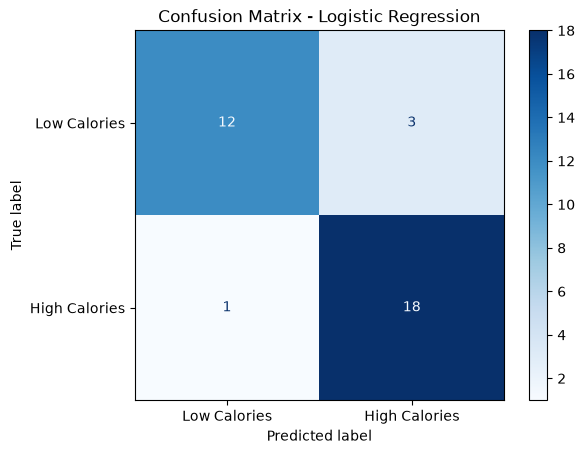

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# สร้าง Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

# แสดงเป็นกราฟ
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Low Calories", "High Calories"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**LAB 3: Model Comparison**

**Simple vs Multiple Linear Regression**

*1) Simple Linear Regression*

R² Score : 0.7471444773251994
Mean Squared Error (MSE) : 8245.553232781873
Coefficient (Slope): 5.755384017808211
Intercept: 5.229634541828489


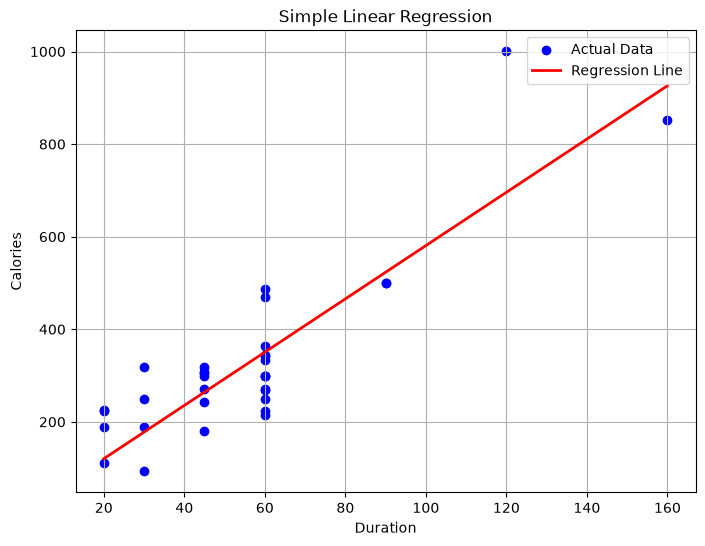

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# อ่านข้อมูล
df = pd.read_csv("data.csv")

# ลบแถวที่ Calories เป็นค่าว่าง (NaN)
df = df.dropna(subset=["Calories"])

# กำหนด Feature และ Target
X = df[["Duration"]]
y = df["Calories"]

# แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# สร้างโมเดล
model = LinearRegression()
model.fit(X_train, y_train)

# ทำนายผล
y_pred = model.predict(X_test)

# ประเมินผล
print("R² Score :", r2_score(y_test, y_pred))
print("Mean Squared Error (MSE) :", mean_squared_error(y_test, y_pred))

# แสดงสมการเส้นตรง
print("Coefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)

# วาดกราฟ
plt.figure(figsize=(8,6))

# จุดข้อมูลจริง
plt.scatter(X_test, y_test, color="blue", label="Actual Data")

# เรียงข้อมูลก่อนวาดเส้น
sorted_index = X_test["Duration"].argsort()

plt.plot(
    X_test.iloc[sorted_index],
    y_pred[sorted_index],
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.title("Simple Linear Regression")
plt.xlabel("Duration")
plt.ylabel("Calories")
plt.legend()
plt.grid(True)
plt.show()

*2) Multiple Linear Regression*

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# อ่านข้อมูล
df = pd.read_csv("data.csv")

# ลบข้อมูลที่ Calories เป็น NaN
df = df.dropna(subset=["Calories"])

# Feature และ Target
X = df[["Duration", "Pulse", "Maxpulse"]]
y = df["Calories"]

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# สร้างโมเดล
model = LinearRegression()
model.fit(X_train, y_train)

# ทำนายผล
y_pred = model.predict(X_test)

# ประเมินผล
print("R² Score :", r2_score(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))

print("\nCoefficients")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

print("\nIntercept:", model.intercept_)

R² Score : 0.8664689420685995
MSE : 4354.413282161514

Coefficients
Duration: 5.7912
Pulse: 1.6709
Maxpulse: 1.9297

Intercept: -435.5672296133219


**Training vs Testing Performance**

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# อ่านข้อมูล
df = pd.read_csv("data.csv")

# ลบข้อมูลที่ Calories เป็น NaN
df = df.dropna(subset=["Calories"])

# Features และ Target
X = df[["Duration", "Pulse", "Maxpulse"]]
y = df["Calories"]

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# สร้างโมเดล
model = LinearRegression()
model.fit(X_train, y_train)

# ทำนายผล
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# ประเมินผล Training
train_r2 = r2_score(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)

# ประเมินผล Testing
test_r2 = r2_score(y_test, test_pred)
test_mse = mean_squared_error(y_test, test_pred)

print("===== Training Performance =====")
print("R² Score :", train_r2)
print("MSE      :", train_mse)

print("\n===== Testing Performance =====")
print("R² Score :", test_r2)
print("MSE      :", test_mse)

===== Training Performance =====
R² Score : 0.8925179863807805
MSE      : 8531.353071565494

===== Testing Performance =====
R² Score : 0.8664689420685995
MSE      : 4354.413282161514


**Regression vs Classification**

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import accuracy_score, confusion_matrix

# อ่านข้อมูล
df = pd.read_csv("data.csv")

# ลบข้อมูลที่ Calories เป็น NaN
df = df.dropna(subset=["Calories"])

# ---------------- Regression ----------------
X = df[["Duration", "Pulse", "Maxpulse"]]
y = df["Calories"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

print("===== Regression =====")
print("R² Score :", r2_score(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))

# ---------------- Classification ----------------
df["Class"] = (df["Calories"] >= 300).astype(int)

X = df[["Duration", "Pulse", "Maxpulse"]]
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("\n===== Classification =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

===== Regression =====
R² Score : 0.8664689420685995
MSE : 4354.413282161514

===== Classification =====
Accuracy : 0.7575757575757576
Confusion Matrix
[[12  4]
 [ 4 13]]


**Regression Metrics (Linear Regression)**

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# อ่านข้อมูล
df = pd.read_csv("data.csv")

# ลบแถวที่ Calories เป็นค่าว่าง
df = df.dropna(subset=["Calories"])

# กำหนด Features และ Target
X = df[["Duration", "Pulse", "Maxpulse"]]
y = df["Calories"]

# แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# สร้างโมเดล
model = LinearRegression()
model.fit(X_train, y_train)

# ทำนายผล
y_pred = model.predict(X_test)

# คำนวณ Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# แสดงผล
print("========== Model Performance Metrics ==========")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")

========== Model Performance Metrics ==========
R² Score : 0.8665
MAE      : 42.0568
MSE      : 4354.4133
RMSE     : 65.9880


**Classification Metrics (Logistic Regression)**

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# อ่านข้อมูล
df = pd.read_csv("data.csv")

# ลบข้อมูลที่มีค่า NaN
df = df.dropna(subset=["Calories"])

# สร้าง Class
df["Class"] = (df["Calories"] >= 300).astype(int)

# Features และ Target
X = df[["Duration", "Pulse", "Maxpulse"]]
y = df["Class"]

# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# สร้างโมเดล
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ทำนายผล
y_pred = model.predict(X_test)

# Performance Metrics
print("===== Classification Metrics =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

===== Classification Metrics =====
Accuracy : 0.7575757575757576
Precision : 0.7142857142857143
Recall : 0.8823529411764706
F1 Score : 0.7894736842105263

Confusion Matrix
[[10  6]
 [ 2 15]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.62      0.71        16
           1       0.71      0.88      0.79        17

    accuracy                           0.76        33
   macro avg       0.77      0.75      0.75        33
weighted avg       0.77      0.76      0.75        33

